<a href="https://colab.research.google.com/github/peanutpirate/Week_7_CodeCamp_2026_Projects_And_Learning_Materials/blob/Projects_Daily/18_Car_Market_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Car Market Exploratory Data Analysis (EDA)

## Project Goal

> The goal of this project is to analyze a used car dataset and understand the structure of the data before building any machine learning models.

> In data science projects, building a model without properly understanding the data can lead to incorrect results. Therefore, Exploratory Data Analysis (EDA) is a critical step in the workflow.

## What is EDA?

> Exploratory Data Analysis (EDA) is the process of examining datasets to summarize their main characteristics using statistics and visualizations.

> EDA helps us to:
* Understand the structure of the data
* Detect missing values
* Identify outliers
* Explore relationships between variables

## Why EDA is Important

> Machine learning models rely heavily on data quality. If the dataset contains missing values, inconsistencies, or extreme outliers, the model may produce unreliable results.

> Therefore, before building any predictive model, we must:
* Explore the dataset
* Visualize patterns
* Clean the data

> This project focuses only on **data understanding, visualization, and cleaning**, without building any machine learning models.

In [ ]:
### 🟦 Hücre 2 – Veriyi Anlamak (8.15)

import pandas as pd

df = pd.read_excel("/content/car_data.xlsx")

df.head()

,year,price,transmission,mileage,tax,mpg,engineSize
0,2005,5200,Automatic,63000,325,32.1,1.8
1,2017,34948,Automatic,27000,20,61.4,2.1
2,2016,49948,Automatic,6200,555,28.0,5.5
3,2016,61948,Automatic,16000,325,30.4,4.0
4,2016,73948,Automatic,4000,325,30.1,4.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13119 entries, 0 to 13118
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          13119 non-null  int64  
 1   price         13119 non-null  int64  
 2   transmission  13119 non-null  object 
 3   mileage       13119 non-null  int64  
 4   tax           13119 non-null  int64  
 5   mpg           13119 non-null  float64
 6   engineSize    13119 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 717.6+ KB


In [ ]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000
mean,2017.296288,24698.596920,21949.559037,129.972178,55.155843,2.071530
std,2.224709,11842.675542,21176.512267,65.260286,15.220082,0.572426
min,1970.000000,650.000000,1.000000,0.000000,1.100000,0.000000
25%,2016.000000,17450.000000,6097.500000,125.000000,45.600000,1.800000
50%,2018.000000,22480.000000,15189.000000,145.000000,56.500000,2.000000
75%,2019.000000,28980.000000,31779.500000,145.000000,64.200000,2.100000
max,2020.000000,159999.000000,259000.000000,580.000000,217.300000,6.200000


In [ ]:
## Dataset Overview

# This dataset contains information about used cars. The main variables include:

# - **Brand** → The manufacturer of the car
# - **Year** → The production year of the car
# - **Mileage** → Total distance the car has driven
# - **Engine Power** → Engine performance (horsepower)
# - **Fuel Type** → Type of fuel used (petrol, diesel, hybrid, etc.)
# - **Price** → Market price of the vehicle

### Variable Types

# Numerical Variables:
# - Year
# - Mileage
# - Engine Power
# - Price

# Categorical Variables:
# - Brand
# - Fuel Type

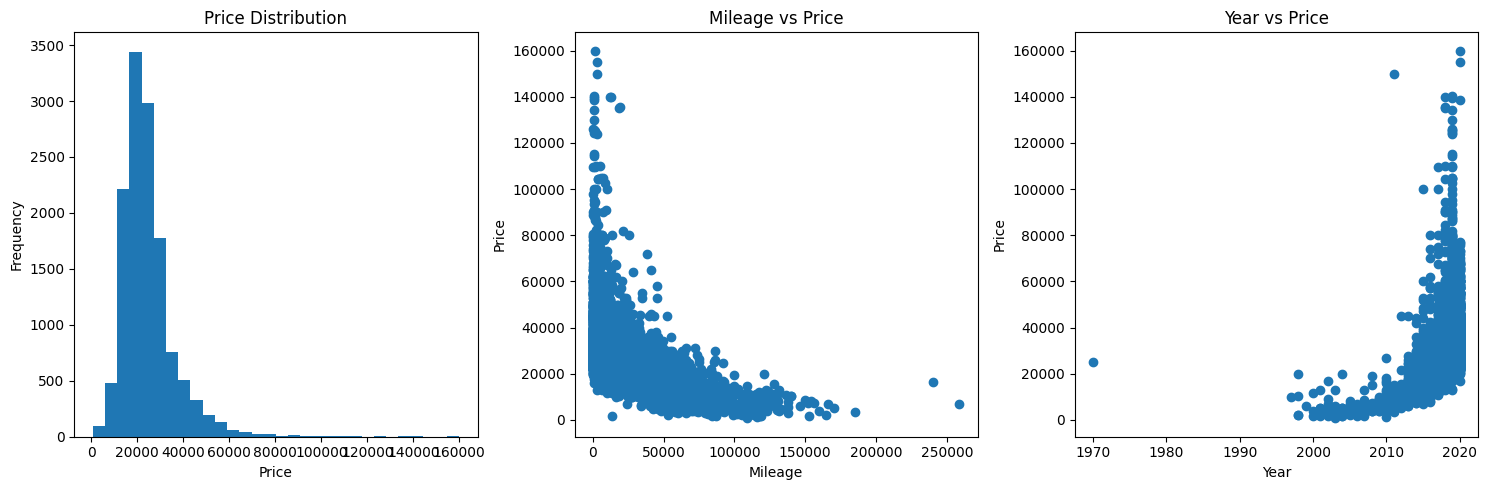

In [13]:
### 🟦 Hücre 3 – Grafiksel Analizler (8.16)

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

# 1️⃣ Fiyat Dağılımı
plt.subplot(1,3,1)
plt.hist(df["price"], bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

# 2️⃣ Kilometre vs Fiyat
plt.subplot(1,3,2)
plt.scatter(df["mileage"], df["price"])
plt.title("Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price")

# 3️⃣ Yıl vs Fiyat
plt.subplot(1,3,3)
plt.scatter(df["year"], df["price"])
plt.title("Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price")

plt.tight_layout()
plt.show()



In [ ]:
### 🟦 Hücre 4 – En Yüksek Fiyatlı Arabalar (8.17)

top_expensive = df.sort_values(by="price", ascending=False).head(10)

top_expensive

,year,price,transmission,mileage,tax,mpg,engineSize
6199,2020,159999,Semi-Auto,1350,145,21.4,4.0
10044,2020,154998,Automatic,3000,150,21.4,4.0
5,2011,149948,Automatic,3000,570,21.4,6.2
8737,2019,140319,Semi-Auto,785,150,22.1,4.0
6386,2018,139995,Semi-Auto,13046,145,21.4,4.0
8,2019,139948,Automatic,12000,145,21.4,4.0
9133,2019,139559,Semi-Auto,1000,145,22.1,4.0
8821,2020,138439,Semi-Auto,1000,145,22.1,4.0
5902,2018,135771,Semi-Auto,19000,145,21.4,4.0
7864,2018,135124,Semi-Auto,18234,150,21.4,4.0


In [ ]:
top_expensive[["year","mileage","transmission","price"]]

,year,mileage,transmission,price
6199,2020,1350,Semi-Auto,159999
10044,2020,3000,Automatic,154998
5,2011,3000,Automatic,149948
8737,2019,785,Semi-Auto,140319
6386,2018,13046,Semi-Auto,139995
8,2019,12000,Automatic,139948
9133,2019,1000,Semi-Auto,139559
8821,2020,1000,Semi-Auto,138439
5902,2018,19000,Semi-Auto,135771
7864,2018,18234,Semi-Auto,135124


In [ ]:
correlation = df.corr(numeric_only=True)

correlation

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.520712,-0.738027,0.012480,-0.094626,-0.142147
price,0.520712,1.000000,-0.537214,0.268717,-0.438445,0.516126
mileage,-0.738027,-0.537214,1.000000,-0.160223,0.202850,0.063652
tax,0.012480,0.268717,-0.160223,1.000000,-0.513742,0.338341
mpg,-0.094626,-0.438445,0.202850,-0.513742,1.000000,-0.339862
engineSize,-0.142147,0.516126,0.063652,0.338341,-0.339862,1.000000


In [ ]:
## Analysis of the Most Expensive Cars

# The top 10 most expensive vehicles generally share some common characteristics:

# - They are relatively **newer models**
# - They usually have **lower mileage**
# - Many of them have **higher engine power**

# This suggests that **vehicle age, mileage, and engine power** play an important role in determining the market price.

In [ ]:
### 🟦 Hücre 5 – Veri Temizliği (8.18)

df.isnull().sum()

,0
year,0
price,0
transmission,0
mileage,0
tax,0
mpg,0
engineSize,0


In [ ]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000
mean,2017.296288,24698.596920,21949.559037,129.972178,55.155843,2.071530
std,2.224709,11842.675542,21176.512267,65.260286,15.220082,0.572426
min,1970.000000,650.000000,1.000000,0.000000,1.100000,0.000000
25%,2016.000000,17450.000000,6097.500000,125.000000,45.600000,1.800000
50%,2018.000000,22480.000000,15189.000000,145.000000,56.500000,2.000000
75%,2019.000000,28980.000000,31779.500000,145.000000,64.200000,2.100000
max,2020.000000,159999.000000,259000.000000,580.000000,217.300000,6.200000


In [ ]:
df = df[df["price"] < 200000]

## Data Cleaning
During the data cleaning process, the following steps were taken:

- Missing values were identified and analyzed.
- Some unrealistic or extreme values were removed.
- Outliers that could negatively affect analysis were filtered.

### Why Cleaning is Important

Cleaning the dataset ensures that future analyses or machine learning models will produce more reliable results.

### 🟦 Son Hücre – İş İçgörüsü (Insight)

Business Insights

Based on the exploratory data analysis, several insights were discovered:

• Higher priced cars are usually newer and have lower mileage.  
• Some older cars with unusually low mileage appear as potential outliers.  
• The dataset contains a few extreme price values that could distort analysis.

Overall, performing data cleaning and exploratory analysis before building any machine learning model is essential to ensure reliable and meaningful results.
